In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

taxis = sns.load_dataset("taxis")

print("| taxis:", taxis.shape)

| taxis: (6433, 14)


In [2]:
taxis["fare_per_mile"] = taxis["fare"] / taxis["distance"]
# Dividing by 0 (rides with distance 0) gives inf — replace with NaN
taxis["fare_per_mile"] = taxis["fare_per_mile"].replace(np.inf, np.nan)

taxis["fare_per_mile"].describe().round(2)

count    6382.00
mean        6.17
std         8.56
min         0.27
25%         4.25
50%         5.42
75%         6.88
max       472.73
Name: fare_per_mile, dtype: float64

In [4]:
print(taxis)
print(taxis.columns.to_list())
print(taxis.dtypes)
taxis[["pickup", "dropoff"]].head(3)

                  pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment            pickup_zone  \
0     2.15    0

,pickup,dropoff
0,2019-03-23 20:21:09,2019-03-23 20:27:24
1,2019-03-04 16:11:55,2019-03-04 16:19:00
2,2019-03-27 17:53:01,2019-03-27 18:00:25


In [5]:
taxis["pickup_hour"] = taxis["pickup"].dt.hour
taxis["pickup_day"] = taxis["pickup"].dt.day_name()
taxis["is_weekend"] = taxis["pickup"].dt.dayofweek >= 5    # Mon=0 ... Sun=6
taxis[["pickup", "pickup_hour", "pickup_day", "is_weekend"]].head()
taxis["duration_min"] = (taxis["dropoff"] - taxis["pickup"]).dt.total_seconds() / 60
taxis["duration_min"].describe().round(1)

count    6433.0
mean       14.3
std        11.6
min         0.0
25%         6.5
50%        10.9
75%        18.5
max       107.7
Name: duration_min, dtype: float64

In [6]:
taxis["borough_avg_fare"] = taxis.groupby("pickup_borough")["fare"].transform("mean")
taxis["fare_vs_borough"] = taxis["fare"] / taxis["borough_avg_fare"]

taxis[["pickup_borough", "fare", "borough_avg_fare", "fare_vs_borough"]].head()

,pickup_borough,fare,borough_avg_fare,fare_vs_borough
0,Manhattan,7.0,11.152889,0.627640
1,Manhattan,5.0,11.152889,0.448314
2,Manhattan,7.5,11.152889,0.672471
3,Manhattan,27.0,11.152889,2.420897
4,Manhattan,9.0,11.152889,0.806966


<a id="8"></a>
## Task 3 — Feature engineering

All exercises use the `taxis` DataFrame (already loaded and with datetimes converted).

**Exercise 1.** Create `total_cost = fare + tip + tolls`, then use `pd.qcut` to bin it into `"cheap"`, `"normal"`, `"expensive"` (3 equal-sized groups). How many rides fall in each?

**Exercise 2.** Create `speed_mph = distance / (duration_min / 60)`. Check it with `.describe()` — do you find suspicious values? Where do they come from?

**Exercise 3.** Using `map`, create a `payment_short` column where `"credit card"` → `"card"` and `"cash"` stays `"cash"`.

**Exercise 4.** Using `groupby().transform()`, add the average `tip` per `pickup_day`, then find which day has the most generous average tip.

**Exercise 5.** Validate one of your new features with a quick plot (e.g. a bar chart of average speed per pickup hour). Write one sentence about what it shows.

In [7]:
# Exercise 1
taxis['total_cost'] = taxis['fare']+ taxis['tip'] + taxis['tolls']
taxis['cost_level'] = pd.qcut(taxis['total_cost'], q=3, labels=['cheap', 'normal', 'expensive'])
taxis['cost_level'].value_counts()

cost_level
cheap        2170
normal       2141
expensive    2122
Name: count, dtype: int64

In [8]:
# Exercise 2
taxis['speed_mph'] = taxis['distance'] / (taxis['duration_min'] / 60)
taxis['speed_mph'].describe()

count    6427.000000
mean       13.090678
std        68.040163
min         0.000000
25%         7.567081
50%        10.042553
75%        13.709845
max      4834.285714
Name: speed_mph, dtype: float64

In [9]:
# Exercise 3
taxis.columns
taxis['payment_short'] = taxis['payment'].map({'credit card': 'card', 'cash': 'cash'})
taxis['payment_short'].value_counts()


payment_short
card    4577
cash    1812
Name: count, dtype: int64

In [10]:
# Exercise 4
taxis['pickup_day'] = taxis['pickup'].dt.day_name()
taxis['avg_tip_by_day'] = taxis.groupby('pickup_day')['tip'].transform('mean')
taxis.groupby('pickup_day')['tip'].mean().sort_values(ascending=False)


pickup_day
Wednesday    2.087329
Thursday     2.062177
Monday       2.027316
Tuesday      2.001370
Friday       1.980108
Sunday       1.908710
Saturday     1.815143
Name: tip, dtype: float64

<Axes: xlabel='pickup_day'>

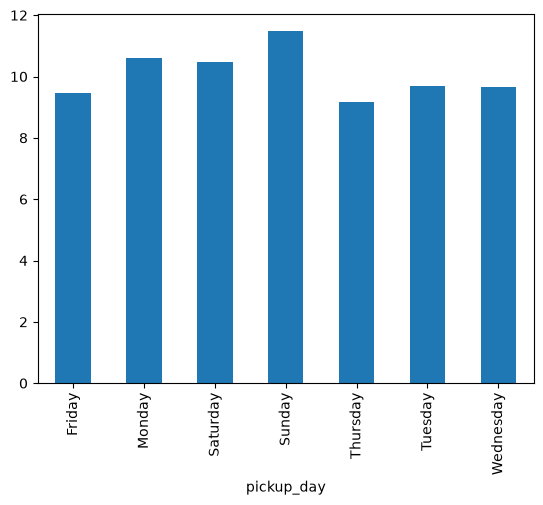

In [12]:
# Exercise 5
taxis.groupby('pickup_day')['speed_mph'].median().plot(kind='bar')